<a href="https://colab.research.google.com/github/tamaravera14/PROCESOS-ESTOCASTICOS/blob/main/Descomposicion_canonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# DESCOMPOSICIÓN CANÓNICA

---

###***Bazaldua Vera Tamara Alheli***

---

##  **1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.**

$$
\textbf{Matriz de transición}
$$

$$
P=
\begin{pmatrix}
\frac14 & 0 & 0 & 0 & 0 & 0 & \frac34\\
\frac18 & \frac18 & \frac14 & 0 & \frac14 & \frac18 & \frac18\\
0 & 0 & \frac25 & \frac15 & \frac25 & 0 & 0\\
0 & 0 & \frac12 & \frac12 & 0 & 0 & 0\\
0 & 0 & 0 & \frac12 & \frac12 & 0 & 0\\
0 & \frac15 & 0 & \frac15 & \frac15 & \frac15 & \frac15\\
\frac45 & 0 & 0 & 0 & 0 & 0 & \frac15
\end{pmatrix}
$$

$$
S=\{a,b,c,d,e,f,g\}
$$

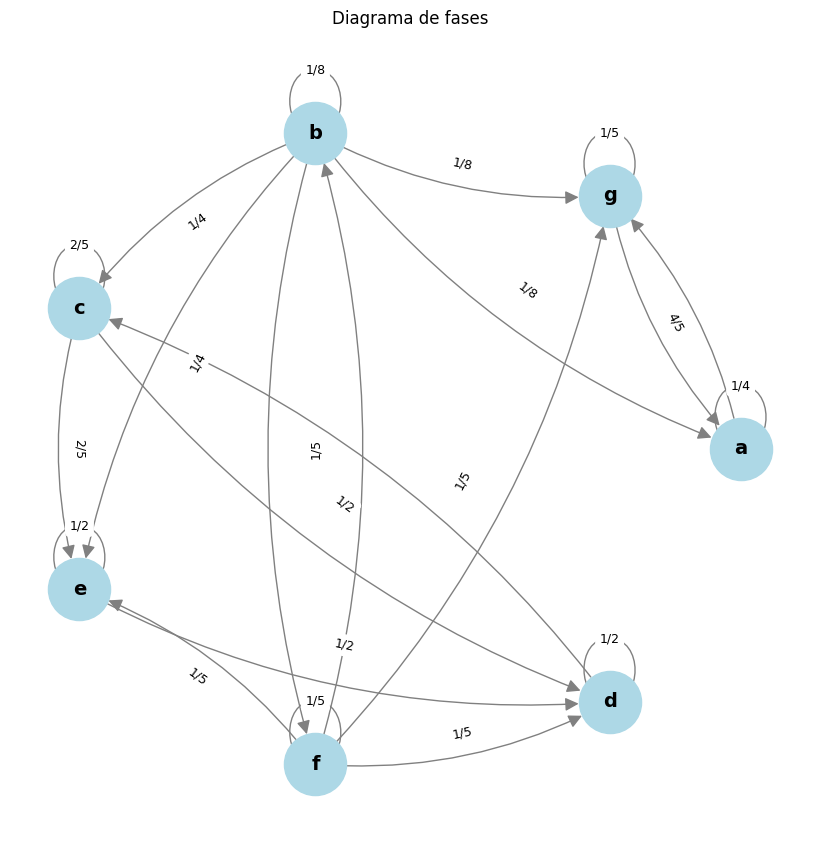

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from fractions import Fraction

# Matriz
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

estados = ["a", "b", "c", "d", "e", "f", "g"]

G = nx.DiGraph()

for i in range(len(estados)):
    for j in range(len(estados)):
        if P[i, j] > 0:
            G.add_edge(estados[i], estados[j], weight=P[i, j])

# Layout circular
pos = nx.circular_layout(G)

# Etiquetas fraccionarias
edge_labels = {
    (u, v): str(Fraction(d["weight"]).limit_denominator())
    for u, v, d in G.edges(data=True)
}

plt.figure(figsize=(8, 8))

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    edge_color="gray",
    font_size=14,
    font_weight="bold",
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.15"
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Diagrama de fases")
plt.axis("off")
plt.show()

---
## **2. Clasificar estados.**

$$
\textbf{Clases comunicantes}
$$

$$
\{a,g\}, \quad \{c,d,e\}, \quad \{b,f\}
$$

$$
\text{Clases recurrentes: } \{a,g\}, \{c,d,e\}
$$

$$
\text{Clase transitoria: } \{b,f\}
$$

---

$$
\textbf{Distribuciones estacionarias}
$$

Para $\{a,g\}$:

$$
\pi^{(1)}=\left(\frac{16}{31},\frac{15}{31}\right)
$$

Para $\{c,d,e\}$:

$$
\pi^{(2)}=\left(\frac13,\frac25,\frac{4}{15}\right)
$$

---

## **3. Determine si la matriz tiene o no distribución límite.**

Se tienen las siguientes clases de la cadena de Markov:

$$
\{a,g\}, \qquad \{c,d,e\}, \qquad \{b,f\}
$$

Las clases

$$
\{a,g\} \quad \text{y} \quad \{c,d,e\}
$$

son clases recurrentes, mientras que

$$
\{b,f\}
$$

es una clase transitoria.

Además, ambas clases cerradas son aperiódicas, ya que:

$$
P_{aa}=\frac{1}{4}, \quad P_{gg}=\frac{1}{5}
$$

y

$$
P_{cc}=\frac{2}{5}, \quad P_{dd}=\frac{1}{2}, \quad P_{ee}=\frac{1}{2}.
$$

Por lo tanto:

$$
\lim_{n \to \infty} P^n \text{ existe.}
$$



> **Sin embargo, no existe una única distribución límite global, ya que hay más de una clase cerrada.**



Para la clase $\{a,g\}$, la distribución estacionaria es:

$$
\pi^{(1)} = \left(\frac{16}{31}, \frac{15}{31}\right)
$$

es decir,

$$
\pi_a = \frac{16}{31}, \qquad \pi_g = \frac{15}{31}.
$$

Para la clase $\{c,d,e\}$, la distribución estacionaria es:

$$
\pi^{(2)} = \left(\frac{1}{3}, \frac{2}{5}, \frac{4}{15}\right)
$$

es decir,

$$
\pi_c = \frac{1}{3}, \qquad \pi_d = \frac{2}{5}, \qquad \pi_e = \frac{4}{15}.
$$

---



> **Conclusión:**



$$
\text{La matriz tiene límite, pero la distribución límite depende del estado inicial.}
$$

Si el estado inicial pertenece a $\{a,g\}$, entonces:

$$
\lim_{n \to \infty} P^n = \pi^{(1)}.
$$

Si el estado inicial pertenece a $\{c,d,e\}$, entonces:

$$
\lim_{n \to \infty} P^n = \pi^{(2)}.
$$

Si el estado inicial pertenece a $\{b,f\}$, eventualmente la cadena entra a alguna de las clases cerradas.

Para escribir la descomposición canónica, reordenamos los estados como:

$$
(b,f \mid a,g \mid c,d,e)
$$

donde:

$$
\{b,f\}
$$

son estados transitorios, y

$$
\{a,g\}, \qquad \{c,d,e\}
$$

son clases cerradas recurrentes.

Entonces la matriz en forma canónica queda:

$$
P_c=
\begin{pmatrix}
Q & R_1 & R_2\\
0 & P_1 & 0\\
0 & 0 & P_2
\end{pmatrix}
$$

donde:

$$
Q=
\begin{pmatrix}
\frac18 & \frac18\\
\frac15 & \frac15
\end{pmatrix}
$$

representa las transiciones entre estados transitorios.

Además,

$$
R_1=
\begin{pmatrix}
\frac18 & \frac18\\
0 & \frac15
\end{pmatrix}
$$

representa las transiciones de los estados transitorios hacia la clase cerrada

$$
\{a,g\}.
$$

También,

$$
R_2=
\begin{pmatrix}
\frac14 & 0 & \frac14\\
0 & \frac15 & \frac15
\end{pmatrix}
$$

representa las transiciones de los estados transitorios hacia la clase cerrada

$$
\{c,d,e\}.
$$

Las submatrices cerradas son:

$$
P_1=
\begin{pmatrix}
\frac14 & \frac34\\
\frac45 & \frac15
\end{pmatrix}
$$

y

$$
P_2=
\begin{pmatrix}
\frac25 & \frac15 & \frac25\\
\frac12 & \frac12 & 0\\
0 & \frac12 & \frac12
\end{pmatrix}.
$$

Por lo tanto, la matriz canónica completa es:

$$
P_c=
\begin{pmatrix}
\frac18 & \frac18 & \frac18 & \frac18 & \frac14 & 0 & \frac14\\
\frac15 & \frac15 & 0 & \frac15 & 0 & \frac15 & \frac15\\
0 & 0 & \frac14 & \frac34 & 0 & 0 & 0\\
0 & 0 & \frac45 & \frac15 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & \frac25 & \frac15 & \frac25\\
0 & 0 & 0 & 0 & \frac12 & \frac12 & 0\\
0 & 0 & 0 & 0 & 0 & \frac12 & \frac12
\end{pmatrix}.
$$

Ahora calculamos la matriz fundamental de los estados transitorios:

$$
N=(I-Q)^{-1}
$$

Como

$$
I-Q=
\begin{pmatrix}
1 & 0\\
0 & 1
\end{pmatrix}
-
\begin{pmatrix}
\frac18 & \frac18\\
\frac15 & \frac15
\end{pmatrix}
=
\begin{pmatrix}
\frac78 & -\frac18\\
-\frac15 & \frac45
\end{pmatrix},
$$

entonces:

$$
N=(I-Q)^{-1}=
\begin{pmatrix}
\frac{32}{27} & \frac{5}{27}\\
\frac{8}{27} & \frac{35}{27}
\end{pmatrix}.
$$

Después calculamos las probabilidades de absorción hacia las clases cerradas.

Para la clase cerrada

$$
\{a,g\},
$$

se tiene:

$$
NR_1=
\begin{pmatrix}
\frac{4}{27} & \frac{5}{27}\\
\frac{1}{27} & \frac{8}{27}
\end{pmatrix}.
$$

Para la clase cerrada

$$
\{c,d,e\},
$$

se tiene:

$$
NR_2=
\begin{pmatrix}
\frac{8}{27} & \frac{1}{27} & \frac13\\
\frac{2}{27} & \frac{7}{27} & \frac13
\end{pmatrix}.
$$

Ahora calculamos las distribuciones límite de las clases cerradas.

Para la submatriz

$$
P_1=
\begin{pmatrix}
\frac14 & \frac34\\
\frac45 & \frac15
\end{pmatrix},
$$

la distribución límite es:

$$
\pi^{(1)}=
\left(
\frac{16}{31},\frac{15}{31}
\right).
$$

Por lo tanto:

$$
\lim_{n\to\infty}P_1^n
=
\begin{pmatrix}
\frac{16}{31} & \frac{15}{31}\\
\frac{16}{31} & \frac{15}{31}
\end{pmatrix}.
$$

Para la submatriz

$$
P_2=
\begin{pmatrix}
\frac25 & \frac15 & \frac25\\
\frac12 & \frac12 & 0\\
0 & \frac12 & \frac12
\end{pmatrix},
$$

la distribución límite es:

$$
\pi^{(2)}=
\left(
\frac13,\frac25,\frac{4}{15}
\right).
$$

Por lo tanto:

$$
\lim_{n\to\infty}P_2^n
=
\begin{pmatrix}
\frac13 & \frac25 & \frac{4}{15}\\
\frac13 & \frac25 & \frac{4}{15}\\
\frac13 & \frac25 & \frac{4}{15}
\end{pmatrix}.
$$

Como los estados transitorios son

$$
\{b,f\},
$$

eventualmente la cadena sale de ellos y entra a alguna de las clases cerradas.

El límite de la potencia n-ésima en el orden canónico

$$
(b,f \mid a,g \mid c,d,e)
$$

es:

$$
\lim_{n\to\infty} P_c^n =
\begin{pmatrix}
0 & 0 & \frac{16}{93} & \frac{5}{31} & \frac29 & \frac{4}{15} & \frac{8}{45}\\
0 & 0 & \frac{16}{93} & \frac{5}{31} & \frac29 & \frac{4}{15} & \frac{8}{45}\\
0 & 0 & \frac{16}{31} & \frac{15}{31} & 0 & 0 & 0\\
0 & 0 & \frac{16}{31} & \frac{15}{31} & 0 & 0 & 0\\
0 & 0 & 0 & 0 & \frac13 & \frac25 & \frac{4}{15}\\
0 & 0 & 0 & 0 & \frac13 & \frac25 & \frac{4}{15}\\
0 & 0 & 0 & 0 & \frac13 & \frac25 & \frac{4}{15}
\end{pmatrix}.
$$

Si regresamos al orden original de los estados,

$$
(a,b,c,d,e,f,g),
$$

obtenemos:

$$
\lim_{n\to\infty}P^n=
\begin{pmatrix}
\frac{16}{31} & 0 & 0 & 0 & 0 & 0 & \frac{15}{31}\\
\frac{16}{93} & 0 & \frac29 & \frac{4}{15} & \frac{8}{45} & 0 & \frac{5}{31}\\
0 & 0 & \frac13 & \frac25 & \frac{4}{15} & 0 & 0\\
0 & 0 & \frac13 & \frac25 & \frac{4}{15} & 0 & 0\\
0 & 0 & \frac13 & \frac25 & \frac{4}{15} & 0 & 0\\
\frac{16}{93} & 0 & \frac29 & \frac{4}{15} & \frac{8}{45} & 0 & \frac{5}{31}\\
\frac{16}{31} & 0 & 0 & 0 & 0 & 0 & \frac{15}{31}
\end{pmatrix}.
$$

Comparando con las distribuciones límite de las submatrices, observamos que las filas correspondientes a la clase

$$
\{a,g\}
$$

coinciden con

$$
\pi^{(1)}=
\left(
\frac{16}{31},\frac{15}{31}
\right),
$$

mientras que las filas correspondientes a la clase

$$
\{c,d,e\}
$$

coinciden con

$$
\pi^{(2)}=
\left(
\frac13,\frac25,\frac{4}{15}
\right).
$$

Por lo tanto, el límite de

$$
P^n
$$

contiene las distribuciones límite de las clases cerradas.

Conclusión:

$$
\boxed{
\lim_{n\to\infty}P^n \text{ existe, pero depende del estado inicial.}
}
$$

Esto ocurre porque la cadena tiene dos clases cerradas:

$$
\{a,g\}
\quad \text{y} \quad
\{c,d,e\}.
$$

Por lo tanto:

$$
\boxed{
P^n \text{ converge, pero no a una única distribución global.}
}
$$

## **4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.**


    Encuentra las clases comunicantes de una matriz de transición P.

    Parámetros
    ----------
    P : numpy.ndarray
        Matriz de transición cuadrada.
    tol : float
        Tolerancia para decidir si una transición existe.

    Regresa
    -------
    clases : list[list[int]]
        Lista de clases comunicantes, usando índices de estados.


In [4]:
import numpy as np
from collections import deque

def encontrar_clases_comunicantes(P, tol=1e-12):

    n = P.shape[0]

    # Construimos el grafo dirigido: i -> j si P[i,j] > 0
    grafo = {i: [j for j in range(n) if P[i, j] > tol] for i in range(n)}

    def alcanzables(origen):
        visitados = set()
        cola = deque([origen])

        while cola:
            actual = cola.popleft()
            if actual not in visitados:
                visitados.add(actual)
                for vecino in grafo[actual]:
                    if vecino not in visitados:
                        cola.append(vecino)

        return visitados # Devuelve los estados alcanzables desde un estado origen.

    # Calculamos alcanzabilidad desde cada estado
    alcance = [alcanzables(i) for i in range(n)]

    # Dos estados comunican si i alcanza a j y j alcanza a i
    no_asignados = set(range(n))
    clases = []

    while no_asignados:
        i = no_asignados.pop()
        clase = {j for j in range(n) if j in alcance[i] and i in alcance[j]}
        clases.append(sorted(clase))
        no_asignados -= clase

    return clases


def clasificar_clases(P, clases, tol=1e-12):
    cerradas = []
    transitorias = []

    for clase in clases:
        clase_set = set(clase)
        es_cerrada = True

        for i in clase:
            for j in range(P.shape[0]):
                if j not in clase_set and P[i, j] > tol:
                    es_cerrada = False

        if es_cerrada:
            cerradas.append(clase)
        else:
            transitorias.append(clase)

    return cerradas, transitorias # Clasifica las clases comunicantes como cerradas o transitorias.

def descomposicion_canonica(P, nombres_estados=None):

    P = np.array(P, dtype=float)
    n = P.shape[0]

    if nombres_estados is None:
        nombres_estados = [str(i) for i in range(n)]

    # Verificación básica
    if P.shape[0] != P.shape[1]:
        raise ValueError("La matriz debe ser cuadrada.")

    if not np.allclose(P.sum(axis=1), 1):
        raise ValueError("Cada fila de P debe sumar 1.")

    clases = encontrar_clases_comunicantes(P)
    cerradas, transitorias = clasificar_clases(P, clases)

    # Orden canónico: primero estados transitorios, luego cerrados
    estados_transitorios = [i for clase in transitorias for i in clase]
    estados_cerrados = [i for clase in cerradas for i in clase]
    nuevo_orden = estados_transitorios + estados_cerrados

    # Reordenamos la matriz
    P_can = P[np.ix_(nuevo_orden, nuevo_orden)]

    t = len(estados_transitorios)

    # Bloque Q: transitorio a transitorio
    Q = P_can[:t, :t]

    # Bloque R: transitorio a cerrado
    R = P_can[:t, t:]

    # Bloques cerrados
    bloques_cerrados = []
    inicio = t

    for clase in cerradas:
        m = len(clase)
        bloque = P_can[inicio:inicio + m, inicio:inicio + m]
        bloques_cerrados.append(bloque)
        inicio += m

    resultado = {
        "clases": clases,
        "clases_cerradas": cerradas,
        "clases_transitorias": transitorias,
        "nuevo_orden_indices": nuevo_orden,
        "nuevo_orden_estados": [nombres_estados[i] for i in nuevo_orden],
        "P_canonica": P_can,
        "Q": Q,
        "R": R,
        "bloques_cerrados": bloques_cerrados
    }

    return resultado

In [12]:
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

estados = ["a", "b", "c", "d", "e", "f", "g"]

resultado = descomposicion_canonica(P, estados)

print("Clases comunicantes:")
for clase in resultado["clases"]:
    print([estados[i] for i in clase])

print("\nClases cerradas:")
for clase in resultado["clases_cerradas"]:
    print([estados[i] for i in clase])

print("\nClases transitorias:")
for clase in resultado["clases_transitorias"]:
    print([estados[i] for i in clase])

print("\nNuevo orden canónico:")
print(resultado["nuevo_orden_estados"])

print("\nMatriz canónica:")
print(resultado["P_canonica"])

print("\nBloque Q:")
print(resultado["Q"])

print("\nBloque R:")
print(resultado["R"])

print("\nBloques cerrados:")
for bloque in resultado["bloques_cerrados"]:
    print(bloque)


Clases comunicantes:
['a', 'g']
['b', 'f']
['c', 'd', 'e']

Clases cerradas:
['a', 'g']
['c', 'd', 'e']

Clases transitorias:
['b', 'f']

Nuevo orden canónico:
['b', 'f', 'a', 'g', 'c', 'd', 'e']

Matriz canónica:
[[0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
 [0.2   0.2   0.    0.2   0.    0.2   0.2  ]
 [0.    0.    0.25  0.75  0.    0.    0.   ]
 [0.    0.    0.8   0.2   0.    0.    0.   ]
 [0.    0.    0.    0.    0.4   0.2   0.4  ]
 [0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5  ]]

Bloque Q:
[[0.125 0.125]
 [0.2   0.2  ]]

Bloque R:
[[0.125 0.125 0.25  0.    0.25 ]
 [0.    0.2   0.    0.2   0.2  ]]

Bloques cerrados:
[[0.25 0.75]
 [0.8  0.2 ]]
[[0.4 0.2 0.4]
 [0.5 0.5 0. ]
 [0.  0.5 0.5]]


In [10]:
import numpy as np
from fractions import Fraction
from collections import deque

# =========================
# FUNCIONES BASE
# =========================

def encontrar_clases_comunicantes(P, tol=1e-12):
    n = P.shape[0]
    grafo = {i: [j for j in range(n) if P[i, j] > tol] for i in range(n)}

    def alcanzables(origen):
        visitados = set()
        cola = deque([origen])
        while cola:
            actual = cola.popleft()
            if actual not in visitados:
                visitados.add(actual)
                for vecino in grafo[actual]:
                    if vecino not in visitados:
                        cola.append(vecino)
        return visitados

    alcance = [alcanzables(i) for i in range(n)]
    no_asignados = set(range(n))
    clases = []

    while no_asignados:
        i = no_asignados.pop()
        clase = {j for j in range(n) if j in alcance[i] and i in alcance[j]}
        clases.append(sorted(clase))
        no_asignados -= clase

    return clases


def clasificar_clases(P, clases, tol=1e-12):
    cerradas = []
    transitorias = []

    for clase in clases:
        clase_set = set(clase)
        es_cerrada = True

        for i in clase:
            for j in range(P.shape[0]):
                if j not in clase_set and P[i, j] > tol:
                    es_cerrada = False

        if es_cerrada:
            cerradas.append(clase)
        else:
            transitorias.append(clase)

    return cerradas, transitorias


def descomposicion_canonica(P, nombres_estados=None):
    P = np.array(P, dtype=float)
    n = P.shape[0]

    if nombres_estados is None:
        nombres_estados = [str(i) for i in range(n)]

    clases = encontrar_clases_comunicantes(P)
    cerradas, transitorias = clasificar_clases(P, clases)

    estados_transitorios = [i for clase in transitorias for i in clase]
    estados_cerrados = [i for clase in cerradas for i in clase]
    nuevo_orden = estados_transitorios + estados_cerrados

    P_can = P[np.ix_(nuevo_orden, nuevo_orden)]
    t = len(estados_transitorios)

    Q = P_can[:t, :t]
    R = P_can[:t, t:]

    bloques_cerrados = []
    inicio = t
    for clase in cerradas:
        m = len(clase)
        bloque = P_can[inicio:inicio + m, inicio:inicio + m]
        bloques_cerrados.append(bloque)
        inicio += m

    return {
        "clases": clases,
        "clases_cerradas": cerradas,
        "clases_transitorias": transitorias,
        "nuevo_orden_indices": nuevo_orden,
        "nuevo_orden_estados": [nombres_estados[i] for i in nuevo_orden],
        "P_canonica": P_can,
        "Q": Q,
        "R": R,
        "bloques_cerrados": bloques_cerrados
    }

# =========================
# FORMATO BONITO
# =========================

def a_str_frac(x):
    f = Fraction(x).limit_denominator()
    if f.denominator == 1:
        return f"{f.numerator}"
    return f"{f.numerator}/{f.denominator}"

def imprimir_matriz(M, nombre=""):
    if nombre:
        print(nombre)
    M_str = [[a_str_frac(x) for x in fila] for fila in M]
    col_widths = [max(len(M_str[i][j]) for i in range(len(M_str))) for j in range(len(M_str[0]))]

    for fila in M_str:
        fila_formateada = "  ".join(f"{val:>{col_widths[j]}}" for j, val in enumerate(fila))
        print(f"| {fila_formateada} |")

# =========================
# MATRIZ
# =========================

P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

estados = ["a", "b", "c", "d", "e", "f", "g"]

resultado = descomposicion_canonica(P, estados)

# =========================
# RESULTADOS
# =========================

print("Clases comunicantes:")
for clase in resultado["clases"]:
    print([estados[i] for i in clase])

print("\nClases cerradas:")
for clase in resultado["clases_cerradas"]:
    print([estados[i] for i in clase])

print("\nClases transitorias:")
for clase in resultado["clases_transitorias"]:
    print([estados[i] for i in clase])

print("\nNuevo orden canónico:")
print(resultado["nuevo_orden_estados"])

print("\nMatriz canónica:")
imprimir_matriz(resultado["P_canonica"])

print("\nBloque Q:")
imprimir_matriz(resultado["Q"])

print("\nBloque R:")
imprimir_matriz(resultado["R"])

print("\nBloques cerrados:")
for i, bloque in enumerate(resultado["bloques_cerrados"], 1):
    print(f"\nBloque {i}:")
    imprimir_matriz(bloque)

Clases comunicantes:
['a', 'g']
['b', 'f']
['c', 'd', 'e']

Clases cerradas:
['a', 'g']
['c', 'd', 'e']

Clases transitorias:
['b', 'f']

Nuevo orden canónico:
['b', 'f', 'a', 'g', 'c', 'd', 'e']

Matriz canónica:
| 1/8  1/8  1/8  1/8  1/4    0  1/4 |
| 1/5  1/5    0  1/5    0  1/5  1/5 |
|   0    0  1/4  3/4    0    0    0 |
|   0    0  4/5  1/5    0    0    0 |
|   0    0    0    0  2/5  1/5  2/5 |
|   0    0    0    0  1/2  1/2    0 |
|   0    0    0    0    0  1/2  1/2 |

Bloque Q:
| 1/8  1/8 |
| 1/5  1/5 |

Bloque R:
| 1/8  1/8  1/4    0  1/4 |
|   0  1/5    0  1/5  1/5 |

Bloques cerrados:

Bloque 1:
| 1/4  3/4 |
| 4/5  1/5 |

Bloque 2:
| 2/5  1/5  2/5 |
| 1/2  1/2    0 |
|   0  1/2  1/2 |


## Descomposición canónica de una matriz de transición

El objetivo del programa es recibir una matriz de transición $$P$$ y encontrar su forma canónica.

Primero se identifican las clases comunicantes. Dos estados $$i$$ y $$j$$ pertenecen a la misma clase si:

$$
i \to j
$$

y

$$
j \to i.
$$

Después se determina cuáles clases son cerradas. Una clase $$C$$ es cerrada si no existen transiciones desde estados de $$C$$ hacia estados fuera de $$C$$.

Finalmente, se reordena la matriz colocando primero los estados transitorios y después las clases cerradas. La forma canónica tiene la estructura:

$$
P_c=
\begin{pmatrix}
Q & R \\
0 & C
\end{pmatrix}
$$

donde:

$$
Q
$$

representa las transiciones entre estados transitorios,

$$
R
$$

representa las transiciones desde estados transitorios hacia clases cerradas,

y

$$
C
$$

contiene las submatrices correspondientes a las clases cerradas.